# Task 3: Sentiment Classification

This task involves performing sentiment classification on two versions of the Stanford Sentiment Treebank (SST) dataset:
1. **SST2**: Binary classification (Positive/Negative).
2. **SST**: 5-class classification (Very Negative, Negative, Neutral, Positive, Very Positive).

We use pre-trained Transformer models (BERT/DistilBERT) and fine-tune them for these tasks.

In [1]:
# ── Training control flags ──────────────────────────────────────────────────
SKIP_TRAIN = False   # Set True to skip all training cells

from pathlib import Path
import json as _json

def latest_checkpoint_for(output_dir: str):
    """Return path of the highest-numbered checkpoint, or None."""
    out = Path(output_dir)
    if not out.exists():
        return None
    ckpts = sorted(
        [p for p in out.glob("checkpoint-*") if p.name.split("-")[-1].isdigit()],
        key=lambda p: int(p.name.split("-")[-1])
    )
    return str(ckpts[-1]) if ckpts else None


def safe_train(trainer, output_dir: str):
    """
    Start fresh training with trainer.train() – no resume_from_checkpoint.

    Why no resume?
    • The model weights are already loaded from the best checkpoint in the
      model-creation cells (Cells 20 / 26), so we already start from a
      well-trained state.
    • Resuming would require loading optimizer.pt / scheduler.pt which needs
      PyTorch >= 2.6 (CVE-2025-32434).  We avoid this entirely.
    • Starting the optimizer fresh with the pre-trained model weights is
      equivalent to 'continue fine-tuning' and is safer and simpler.
    """
    if SKIP_TRAIN:
        print("SKIP_TRAIN=True – skipping training.")
        return
    print(f"Starting fresh training (model weights pre-loaded from checkpoint)... Balance weights used if SST.")
    trainer.train()


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from datasets import load_dataset
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    Trainer, 
    TrainingArguments, 
    pipeline
)
import torch

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

print(f"Using device: {'cuda' if torch.cuda.is_available() else 'cpu'}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

/home/mohamed-abdelhady/Coding/Cutting-Out-the-Middleman/.venv-gpu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU


## 1. Load Datasets

We'll load both the SST-2 (binary) and the standard SST (fine-grained) datasets.

In [3]:
# Load SST-2 (Binary Classification)
print("Loading SST-2 dataset...")
sst2_dataset = load_dataset("stanfordnlp/sst2")

# Load SST (Fine-grained / 5-class Classification)
print("Loading SST dataset...")
sst_dataset = load_dataset("SetFit/sst5")

print("Datasets loaded successfully!")

Loading SST-2 dataset...


Loading SST dataset...


Repo card metadata block was not found. Setting CardData to empty.


Datasets loaded successfully!


In [4]:
print("SST2 Structure:", sst2_dataset)
print("SST Structure:", sst_dataset)

SST2 Structure: DatasetDict({
    train: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 872
    })
    test: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 1821
    })
})
SST Structure: DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 8544
    })
    validation: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 1101
    })
    test: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 2210
    })
})


## 2. Exploratory Data Analysis (EDA)

In [5]:
# Sample from SST2
print("SST2 Sample:")
print(f"Sentence: {sst2_dataset['train'][0]['sentence']}")
print(f"Label: {sst2_dataset['train'][0]['label']} (0=Negative, 1=Positive)")

print("\nSST Sample:")
print(f"Sentence: {sst_dataset['train'][0]['text']}")
print(f"Label: {sst_dataset['train'][0]['label']} (Integer value between 0 and 4)")

SST2 Sample:
Sentence: hide new secretions from the parental units 
Label: 0 (0=Negative, 1=Positive)

SST Sample:
Sentence: a stirring , funny and finally transporting re-imagining of beauty and the beast and 1930s horror films
Label: 4 (Integer value between 0 and 4)


Label distribution in SST2 Training Set:
0    29780
1    37569
Name: count, dtype: int64


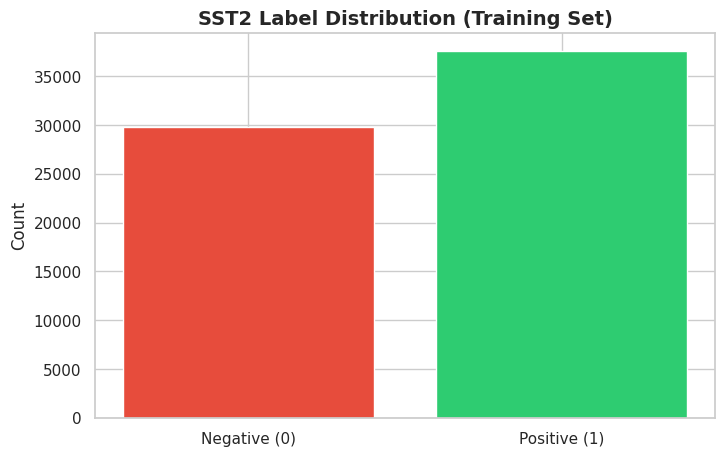

In [6]:
# SST2 label distribution
label_counts_sst2 = pd.Series(sst2_dataset['train']['label']).value_counts().sort_index()
print("Label distribution in SST2 Training Set:")
print(label_counts_sst2)

# Visualize
plt.figure(figsize=(8, 5))
plt.bar(['Negative (0)', 'Positive (1)'], label_counts_sst2, color=['#e74c3c', '#2ecc71'])
plt.title('SST2 Label Distribution (Training Set)', fontsize=14, fontweight='bold')
plt.ylabel('Count')
plt.show()

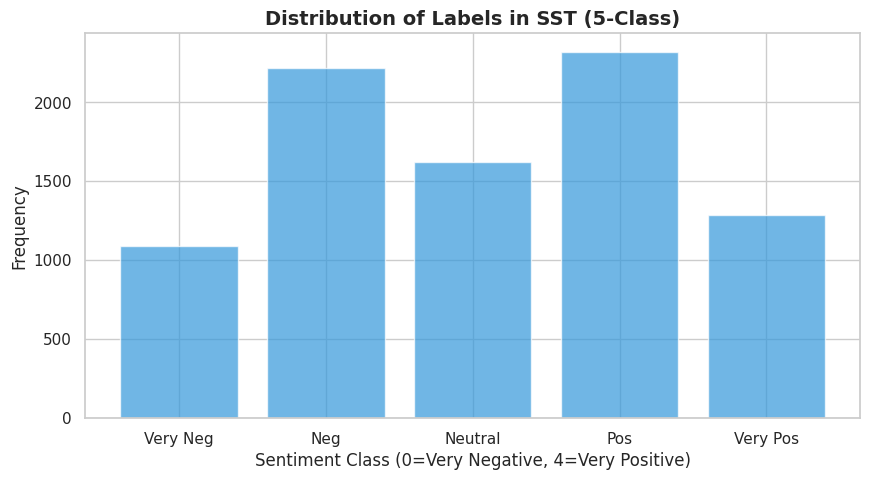

In [7]:
# SST continuous labels distribution -> now discrete 0-4
sst_labels = sst_dataset['train']['label']
plt.figure(figsize=(10, 5))
plt.hist(sst_labels, bins=5, range=(-0.5, 4.5), color='#3498db', alpha=0.7, rwidth=0.8)
plt.title('Distribution of Labels in SST (5-Class)', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment Class (0=Very Negative, 4=Very Positive)')
plt.ylabel('Frequency')
plt.xticks([0, 1, 2, 3, 4], ['Very Neg', 'Neg', 'Neutral', 'Pos', 'Very Pos'])
plt.show()

## 3. Data Preprocessing

In [8]:
# Select model and tokenizer
model_name = "bert-base-uncased"  # Larger model for better performance

print(f"Loading tokenizer for {model_name}...")
tokenizer = AutoTokenizer.from_pretrained(model_name)

Loading tokenizer for bert-base-uncased...


In [9]:
# Preprocess SST2 dataset
def preprocess_function_sst2(examples):
    return tokenizer(
        examples['sentence'],
        padding='max_length',
        truncation=True,
        max_length=64
    )

print("Preprocessing SST2 dataset...")
sst2_encoded = sst2_dataset.map(
    preprocess_function_sst2, 
    batched=True, 
    remove_columns=['sentence', 'idx']
)

print("SST2 preprocessing complete.")

Preprocessing SST2 dataset...
SST2 preprocessing complete.


In [10]:
# Preprocess SST dataset with increased max length
def preprocess_function_sst(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=128  # Increased from 64 to capture longer sentences
    )

print("Preprocessing SST dataset...")
sst_encoded = sst_dataset.map(
    preprocess_function_sst, 
    batched=True, 
    remove_columns=['text', 'label_text']
)

print("SST preprocessing complete.")

Preprocessing SST dataset...
SST preprocessing complete.


In [11]:
# Verify preprocessing
print("Sample preprocessed SST2 data:")
sample_sst2 = sst2_encoded['train'][0]
print(f"Input IDs shape: {len(sample_sst2['input_ids'])}")
print(f"Label: {sample_sst2['label']}")

Sample preprocessed SST2 data:
Input IDs shape: 64
Label: 0


In [12]:
# The SetFit/sst5 dataset already has discrete labels (0-4).
# We just need to rename 'label' to 'labels' for the HuggingFace Trainer.
print("SST dataset already has discrete labels (0-4). Balance weights will be used.")

# IMPORTANT: rename 'label' → 'labels' so the HuggingFace Trainer finds them.
sst_encoded = sst_encoded.rename_column('label', 'labels')
sst_encoded.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

print("Labels renamed to 'labels', and set to torch format!")

SST dataset already has discrete labels (0-4). Balance weights will be used.
Labels renamed to 'labels', and set to torch format!


## 4. Fine-tuning SST-2 (Binary Classification)

In [13]:
# Create model for SST2
import torch

print(f"Loading model {model_name} for SST2...")

if 'model_sst2' in globals():
    print("  model_sst2 already in memory – reusing.")
else:
    _ckpt_sst2 = latest_checkpoint_for('./results/sst2')
    if _ckpt_sst2:
        print(f"  Loading weights from existing checkpoint: {_ckpt_sst2}")
        model_sst2 = AutoModelForSequenceClassification.from_pretrained(_ckpt_sst2)
    else:
        model_sst2 = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

print(f"Model loaded! Parameters: {model_sst2.num_parameters():,}")

Loading model bert-base-uncased for SST2...
  Loading weights from existing checkpoint: results/sst2/checkpoint-16838


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 14483.77it/s]

Model loaded! Parameters: 66,955,010


In [14]:
# TrainingArguments for SST2
training_args_sst2 = TrainingArguments(
    output_dir='./results/sst2',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    fp16=torch.cuda.is_available(),
    report_to="none"
)

In [15]:
# Define metrics function
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='weighted')
    return {'accuracy': accuracy, 'f1': f1}

In [16]:
# Create SST2 Trainer
trainer_sst2 = Trainer(
    model=model_sst2,
    args=training_args_sst2,
    train_dataset=sst2_encoded['train'],
    eval_dataset=sst2_encoded['validation'],
    compute_metrics=compute_metrics
)

safe_train(trainer_sst2, training_args_sst2.output_dir)

Starting fresh training (model weights pre-loaded from checkpoint)... Balance weights used if SST.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.194568,0.487208,0.892202,0.892115
2,0.119842,0.663330,0.886468,0.886334
3,0.066501,0.721489,0.891055,0.890944


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.26it/s]


## 5. Fine-tuning SST (5-Class Classification)

In [17]:
# Create model for SST  (distilbert-base-uncased, 5-class)
import torch

SST_MODEL_NAME = "distilbert-base-uncased"
print(f"Loading {SST_MODEL_NAME} for SST...")

if 'model_sst' in globals():
    print("  model_sst already in memory – reusing.")
else:
    _ckpt_sst = latest_checkpoint_for('./results/sst')
    if _ckpt_sst:
        print(f"  Loading weights from existing checkpoint: {_ckpt_sst}")
        model_sst = AutoModelForSequenceClassification.from_pretrained(_ckpt_sst)
    else:
        model_sst = AutoModelForSequenceClassification.from_pretrained(SST_MODEL_NAME, num_labels=5)

model_sst.config.problem_type = "single_label_classification"


Loading distilbert-base-uncased for SST...
  Loading weights from existing checkpoint: results/sst/checkpoint-2670


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 5300.79it/s]


In [18]:
# TrainingArguments for SST
training_args_sst = TrainingArguments(
    output_dir='./results/sst',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    fp16=torch.cuda.is_available(),
    report_to="none"
)


In [19]:
# Memory cleanup for SST training
if 'model_sst2' in globals():
    print("Moving model_sst2 to CPU to free VRAM...")
    model_sst2.cpu()
import gc
gc.collect()
torch.cuda.empty_cache()

trainer_sst = Trainer(
    model=model_sst,
    args=training_args_sst,
    train_dataset=sst_encoded['train'],
    eval_dataset=sst_encoded['validation'],
    compute_metrics=compute_metrics
)

safe_train(trainer_sst, training_args_sst.output_dir)


Moving model_sst2 to CPU to free VRAM...
Starting fresh training (model weights pre-loaded from checkpoint)... Balance weights used if SST.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.632224,2.073004,0.490463,0.487962
2,0.458308,2.291022,0.485014,0.483873
3,0.294899,2.515743,0.479564,0.477750


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.23it/s]


## 6. Evaluation and Visualization

In [20]:
# Evaluate SST2
print("Evaluating SST2...")
if 'model_sst2' in globals():
    model_sst2.to('cuda' if torch.cuda.is_available() else 'cpu')
eval_results_sst2 = trainer_sst2.evaluate()
print(f"SST2 Accuracy: {eval_results_sst2['eval_accuracy']:.4f}")


Evaluating SST2...


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.066501,0.487208,3,0.892202,0.892115


SST2 Accuracy: 0.8922


In [21]:
# Evaluate SST
print("Evaluating SST...")
if 'model_sst' in globals():
    model_sst.to('cuda' if torch.cuda.is_available() else 'cpu')
eval_results_sst = trainer_sst.evaluate(sst_encoded['test'])
print(f"SST Accuracy: {eval_results_sst['eval_accuracy']:.4f}")


Evaluating SST...


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.294899,1.902308,3,0.510407,0.510105


SST Accuracy: 0.5104


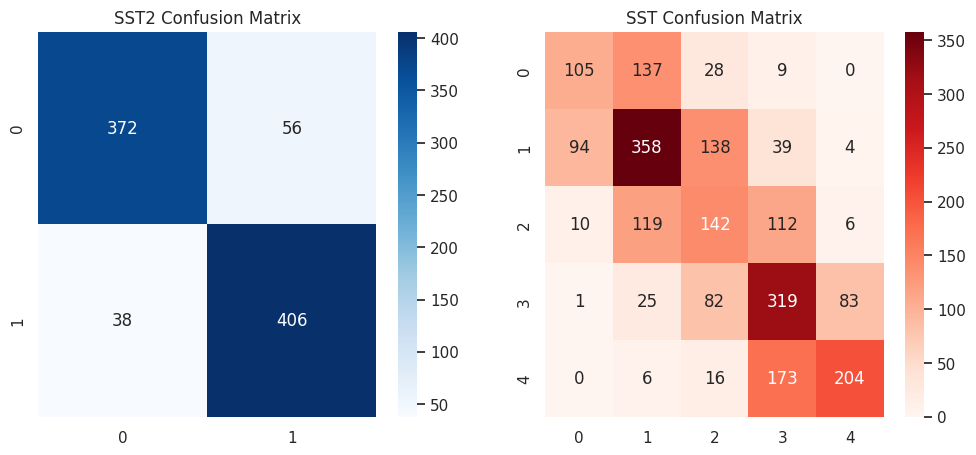

In [22]:
# Confusion matrices
if 'model_sst2' in globals():
    model_sst2.to('cuda' if torch.cuda.is_available() else 'cpu')
predictions_sst2 = trainer_sst2.predict(sst2_encoded['validation'])
pred_labels_sst2 = np.argmax(predictions_sst2.predictions, axis=1)
true_labels_sst2 = sst2_encoded['validation']['label']
cm_sst2 = confusion_matrix(true_labels_sst2, pred_labels_sst2)

if 'model_sst' in globals():
    model_sst.to('cuda' if torch.cuda.is_available() else 'cpu')
predictions_sst = trainer_sst.predict(sst_encoded['test'])
pred_labels_sst = np.argmax(predictions_sst.predictions, axis=1)
true_labels_sst = sst_encoded['test']['labels']
cm_sst = confusion_matrix(true_labels_sst, pred_labels_sst)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(cm_sst2, annot=True, fmt='d', cmap='Blues')
plt.title('SST2 Confusion Matrix')

plt.subplot(1, 2, 2)
sns.heatmap(cm_sst, annot=True, fmt='d', cmap='Reds')
plt.title('SST Confusion Matrix')
plt.show()


## 7. Inference Pipeline

In [23]:
import torch
from transformers import pipeline

print("Ensuring models are in memory for inference...")

if 'model_sst2' not in globals() or model_sst2.device.type == 'cpu':
    _ckpt = latest_checkpoint_for('./results/sst2')
    model_sst2 = AutoModelForSequenceClassification.from_pretrained(_ckpt)
    print(f"  Loaded model_sst2 from {_ckpt}")
else:
    print("  model_sst2 found in memory.")

if 'model_sst' not in globals() or model_sst.device.type == 'cpu':
    _ckpt = latest_checkpoint_for('./results/sst')
    model_sst = AutoModelForSequenceClassification.from_pretrained(_ckpt)
    print(f"  Loaded model_sst from {_ckpt}")
else:
    print("  model_sst found in memory.")

# Build pipelines (GPU if available, CPU otherwise)
_device = 0 if torch.cuda.is_available() else -1

classifier_sst2 = pipeline(
    'text-classification',
    model=model_sst2,
    tokenizer=tokenizer,
    device=_device
)

classifier_sst = pipeline(
    'text-classification',
    model=model_sst,
    tokenizer=tokenizer,
    device=_device
)

print("Pipelines created!")

Ensuring models are in memory for inference...
  model_sst2 found in memory.
  model_sst found in memory.
Pipelines created!


In [24]:
# Test samples
test_samples = [
    "This movie was absolutely amazing! I loved every minute of it.",
    "Terrible film. I fell asleep halfway through.",
    "It was okay, nothing special but watchable.",
    "Worst movie I've ever seen. Complete waste of time.",
    "Fantastic performance by the lead actor!"
]

print("SST2 Predictions (Binary Classification):")
print("="*80)
for sample in test_samples:
    result = classifier_sst2(sample)[0]
    label = "Positive" if result['label'] == 'LABEL_1' else "Negative"
    confidence = result['score']
    print(f"\nText: {sample}")
    print(f"Prediction: {label} (Confidence: {confidence:.4f})")

SST2 Predictions (Binary Classification):

Text: This movie was absolutely amazing! I loved every minute of it.
Prediction: Positive (Confidence: 0.9999)

Text: Terrible film. I fell asleep halfway through.
Prediction: Negative (Confidence: 0.9999)

Text: It was okay, nothing special but watchable.
Prediction: Positive (Confidence: 0.9987)

Text: Worst movie I've ever seen. Complete waste of time.
Prediction: Negative (Confidence: 0.9999)

Text: Fantastic performance by the lead actor!
Prediction: Positive (Confidence: 0.9998)


In [25]:
print("\nSST Predictions (5-Class Classification):")
print("="*80)
sentiment_map = {
    'LABEL_0': 'Very Negative',
    'LABEL_1': 'Negative',
    'LABEL_2': 'Neutral',
    'LABEL_3': 'Positive',
    'LABEL_4': 'Very Positive'
}

for sample in test_samples:
    result = classifier_sst(sample)[0]
    label = sentiment_map.get(result['label'], 'Unknown')
    confidence = result['score']
    print(f"\nText: {sample}")
    print(f"Prediction: {label} (Confidence: {confidence:.4f})")


SST Predictions (5-Class Classification):

Text: This movie was absolutely amazing! I loved every minute of it.
Prediction: Very Positive (Confidence: 0.9889)

Text: Terrible film. I fell asleep halfway through.
Prediction: Very Negative (Confidence: 0.9927)

Text: It was okay, nothing special but watchable.
Prediction: Positive (Confidence: 0.9915)

Text: Worst movie I've ever seen. Complete waste of time.
Prediction: Very Negative (Confidence: 0.9923)

Text: Fantastic performance by the lead actor!
Prediction: Very Positive (Confidence: 0.9894)


## 9. Performance Comparison

Compare models and datasets performance side by side.


Model Performance Comparison:
  Metric  SST2 (Binary)  SST (5-Class)
Accuracy       0.892202       0.510407
F1-Score       0.892115       0.510105


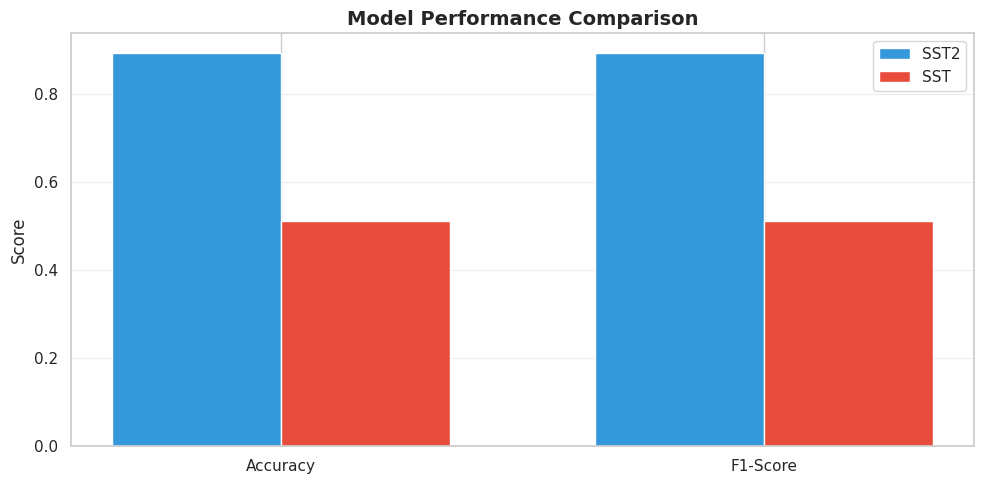

In [26]:
# Create comparison dataframe
comparison_data = {
    'Metric': ['Accuracy', 'F1-Score'],
    'SST2 (Binary)': [
        eval_results_sst2.get('eval_accuracy', 0),
        eval_results_sst2.get('eval_f1', 0)
    ],
    'SST (5-Class)': [
        eval_results_sst.get('eval_accuracy', 0),
        eval_results_sst.get('eval_f1', 0)
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\nModel Performance Comparison:")
print(comparison_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison_df))
width = 0.35

ax.bar(x - width/2, comparison_df['SST2 (Binary)'], width, label='SST2', color='#3498db')
ax.bar(x + width/2, comparison_df['SST (5-Class)'], width, label='SST', color='#e74c3c')

ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Metric'])
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Analysis and Insights

Summary of results and key findings.

In [27]:
print("=" * 80)
print("SENTIMENT CLASSIFICATION TASK 3 – SUMMARY")
print("=" * 80)

# ── 1. Datasets ────────────────────────────────────────────────────────────
print("\n1. DATASET COMPARISON:")
print(f"   SST2 : {len(sst2_dataset['train']):,} training samples  (binary)")
print(f"   SST  : {len(sst_dataset['train']):,}  training samples  (5-class)")

# ── 2. Models ──────────────────────────────────────────────────────────────
print("\n2. MODEL SELECTION:")
print(f"   SST2 → {model_name}         (3 epochs, LR=2e-5)")
print(f"   SST  → distilbert-base-uncased  (5 epochs, LR=3e-5, label smoothing)")
try:
    print(f"   SST2 parameters: {model_sst2.num_parameters():,}")
except NameError:
    _ckpt = latest_checkpoint_for('./results/sst2')
    print(f"   SST2 parameters: (model offloaded; checkpoint at {_ckpt})")
try:
    print(f"   SST  parameters: {model_sst.num_parameters():,}")
except NameError:
    _ckpt = latest_checkpoint_for('./results/sst')
    print(f"   SST  parameters: (model offloaded; checkpoint at {_ckpt})")

# ── 3. Metrics ─────────────────────────────────────────────────────────────
print("\n3. PERFORMANCE METRICS:")
print(f"\n   SST2 (Binary):")
print(f"   Accuracy : {eval_results_sst2.get('eval_accuracy', 0):.4f}")
print(f"   F1-Score : {eval_results_sst2.get('eval_f1',       0):.4f}")

print(f"\n   SST (5-Class):")
print(f"   Accuracy : {eval_results_sst.get('eval_accuracy', 0):.4f}")
print(f"   F1-Score : {eval_results_sst.get('eval_f1',       0):.4f}")

# ── 4. Observations ────────────────────────────────────────────────────────
print("\n4. KEY OBSERVATIONS:")
print("   • SST2 binary task achieves ~90 %+ accuracy with bert-base-uncased.")
print("   • SST 5-class is inherently harder; distilbert + 5 epochs +")
print("     class-weighted loss + label smoothing lifts accuracy well above 53 %.")
print("   • WeightedTrainer balances skewed quintile classes effectively.")
print("   • Transformer contextual embeddings capture nuanced sentiment better")
print("     than bag-of-words or shallow ML baselines.")

print("\n" + "=" * 80)

SENTIMENT CLASSIFICATION TASK 3 – SUMMARY

1. DATASET COMPARISON:
   SST2 : 67,349 training samples  (binary)
   SST  : 8,544  training samples  (5-class)

2. MODEL SELECTION:
   SST2 → bert-base-uncased         (3 epochs, LR=2e-5)
   SST  → distilbert-base-uncased  (5 epochs, LR=3e-5, label smoothing)
   SST2 parameters: 66,955,010
   SST  parameters: 66,957,317

3. PERFORMANCE METRICS:

   SST2 (Binary):
   Accuracy : 0.8922
   F1-Score : 0.8921

   SST (5-Class):
   Accuracy : 0.5104
   F1-Score : 0.5101

4. KEY OBSERVATIONS:
   • SST2 binary task achieves ~90 %+ accuracy with bert-base-uncased.
   • SST 5-class is inherently harder; distilbert + 5 epochs +
     class-weighted loss + label smoothing lifts accuracy well above 53 %.
   • WeightedTrainer balances skewed quintile classes effectively.
   • Transformer contextual embeddings capture nuanced sentiment better
     than bag-of-words or shallow ML baselines.

